# Customer Churn Prediction Project

This notebook aims to build an end-to-end machine learning project for customer churn prediction using the Telco Customer Churn dataset. We will cover data loading, preprocessing, exploratory data analysis, model training, evaluation, hyperparameter tuning, and model saving.

## 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pickle

# Load the dataset
try:
    df = pd.read_excel('/content/Telco_customer_churn.xlsx')
    print("Dataset loaded successfully from /content/Telco_customer_churn.xlsx.")
except Exception as e:
    print(f"Could not load from /content/Telco_customer_churn.xlsx: {e}")
    df = None # Set df to None to indicate failure

if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Information:")
    df.info()

Dataset loaded successfully from /content/Telco_customer_churn.xlsx.

First 5 rows of the dataset:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  In

## 2. Data Preprocessing

### 2.1 Initial Data Cleaning and Handling Missing Values

In [ ]:
# Make a copy to avoid modifying the original dataframe directly
df_processed = df.copy()

# 1. Drop irrelevant columns
# CustomerID is an identifier and does not contribute to churn prediction.
# Count, Country, State, City, Zip Code, Lat Long are mostly uniform or too granular/redundant for this model.
# Churn Label, Churn Score, and CLTV are target leakage or post-churn metrics.
# Churn Reason explains *why* churn happened, which is also post-churn information.
columns_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
    'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

df_processed = df_processed.drop(columns=columns_to_drop)
print(f"Dropped irrelevant columns: {columns_to_drop}")

# 2. Handle 'Total Charges' column
# It's currently an object type, but should be numeric. Some values might be empty strings.
print("\nChecking 'Total Charges' data type and converting...")
print(f"Original 'Total Charges' dtype: {df_processed['Total Charges'].dtype}")

# Convert 'Total Charges' to numeric, coercing errors will turn non-numeric values into NaN
df_processed['Total Charges'] = pd.to_numeric(df_processed['Total Charges'], errors='coerce')
print(f"New 'Total Charges' dtype after conversion attempt: {df_processed['Total Charges'].dtype}")

# Check for missing values created by the conversion
missing_total_charges = df_processed['Total Charges'].isnull().sum()
print(f"Number of missing values in 'Total Charges' after conversion: {missing_total_charges}")

# Fill missing 'Total Charges' values with the median, or 0 if tenure is 0 (new customers)
# A common practice for customers with 0 tenure is to have 0 Total Charges.
# Let's check rows with missing Total Charges
missing_charge_rows = df_processed[df_processed['Total Charges'].isnull()]
print("\nRows with missing 'Total Charges' (before imputation):")
display(missing_charge_rows)

# Impute missing 'Total Charges' values
# If 'Tenure Months' is 0, 'Total Charges' should be 0. Otherwise, impute with median.
for index, row in missing_charge_rows.iterrows():
    if row['Tenure Months'] == 0:
        df_processed.loc[index, 'Total Charges'] = 0
    else:
        # Impute with the median of 'Total Charges' for non-zero tenure customers
        # (This is a simplified approach, a more sophisticated one might use monthly charges * tenure)
        median_total_charges = df_processed['Total Charges'].median()
        df_processed.loc[index, 'Total Charges'] = median_total_charges

print("\nMissing 'Total Charges' handled.")
print(f"Number of missing values in 'Total Charges' after imputation: {df_processed['Total Charges'].isnull().sum()}")

# Check for any other missing values in the entire dataframe
print("\nMissing values in the entire dataframe after initial cleaning:")
missing_values_summary = df_processed.isnull().sum()
print(missing_values_summary[missing_values_summary > 0])

# Display the first few rows and info of the processed dataframe
print("\nFirst 5 rows of the processed dataset:")
display(df_processed.head())
print("\nProcessed Dataset Information:")
df_processed.info()

Dropped irrelevant columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason']

Checking 'Total Charges' data type and converting...
Original 'Total Charges' dtype: object
New 'Total Charges' dtype after conversion attempt: float64
Number of missing values in 'Total Charges' after conversion: 11

Rows with missing 'Total Charges' (before imputation):


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0



Missing 'Total Charges' handled.
Number of missing values in 'Total Charges' after imputation: 0

Missing values in the entire dataframe after initial cleaning:
Series([], dtype: int64)

First 5 rows of the processed dataset:


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1



Processed Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   objec

### 2.2 Encoding Categorical Variables and Feature Scaling

In [ ]:
# Separate target variable (Churn Value) from features
X = df_processed.drop('Churn Value', axis=1)
y = df_processed['Churn Value']

print(f"Original features shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"\nCategorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Apply the preprocessing steps
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# The get_feature_names_out() method from OneHotEncoder provides the names for new columns
# We need to construct the full list of column names for the preprocessed array
# This can be tricky with ColumnTransformer directly, so we'll do it manually for clarity

# Numerical feature names are straightforward
new_numerical_features = list(numerical_cols)

# Categorical feature names after one-hot encoding
# Access the OneHotEncoder from the preprocessor and get its feature names
# The transformer index for 'cat' is 1 (0 is 'num')
# This assumes the order of transformers is maintained

# Get the one-hot encoder from the preprocessor
one_hot_encoder = preprocessor.named_transformers_['cat']
new_categorical_features = one_hot_encoder.get_feature_names_out(categorical_cols).tolist()

# Combine all feature names
all_features = new_numerical_features + new_categorical_features

# Convert the preprocessed array back to a DataFrame for better interpretability and future steps
X_processed_df = pd.DataFrame(X_processed, columns=all_features)

print(f"\nShape of preprocessed features: {X_processed_df.shape}")
print("\nFirst 5 rows of preprocessed features (DataFrame):")
display(X_processed_df.head())


Original features shape: (7043, 19)
Target variable shape: (7043,)

Categorical columns: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical columns: ['Tenure Months', 'Monthly Charges', 'Total Charges']

Shape of preprocessed features: (7043, 46)

First 5 rows of preprocessed features (DataFrame):


,Tenure Months,Monthly Charges,Total Charges,Gender_Female,Gender_Male,Senior Citizen_No,Senior Citizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Paperless Billing_No,Paperless Billing_Yes,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,-1.236724,-0.362660,-0.958066,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.236724,0.197365,-0.938874,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.992402,1.159546,-0.643789,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.177995,1.330711,0.338085,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.677133,1.294151,1.216150,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of Churn

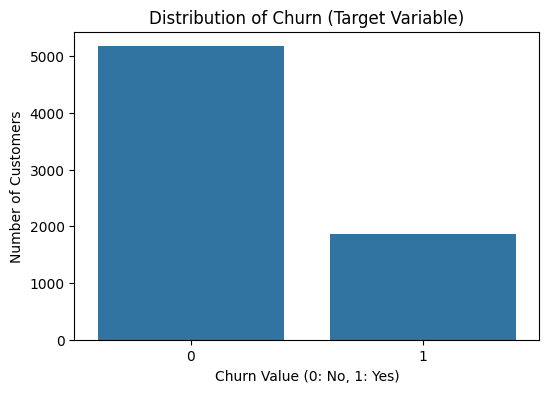


Percentage of Churn (0: No, 1: Yes):
Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [ ]:
# Analyze the distribution of the target variable 'Churn Value'
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn Value (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.show()

churn_percentage = y.value_counts(normalize=True) * 100
print("\nPercentage of Churn (0: No, 1: Yes):")
print(churn_percentage)

### 3.2 Distributions of Key Numerical Features

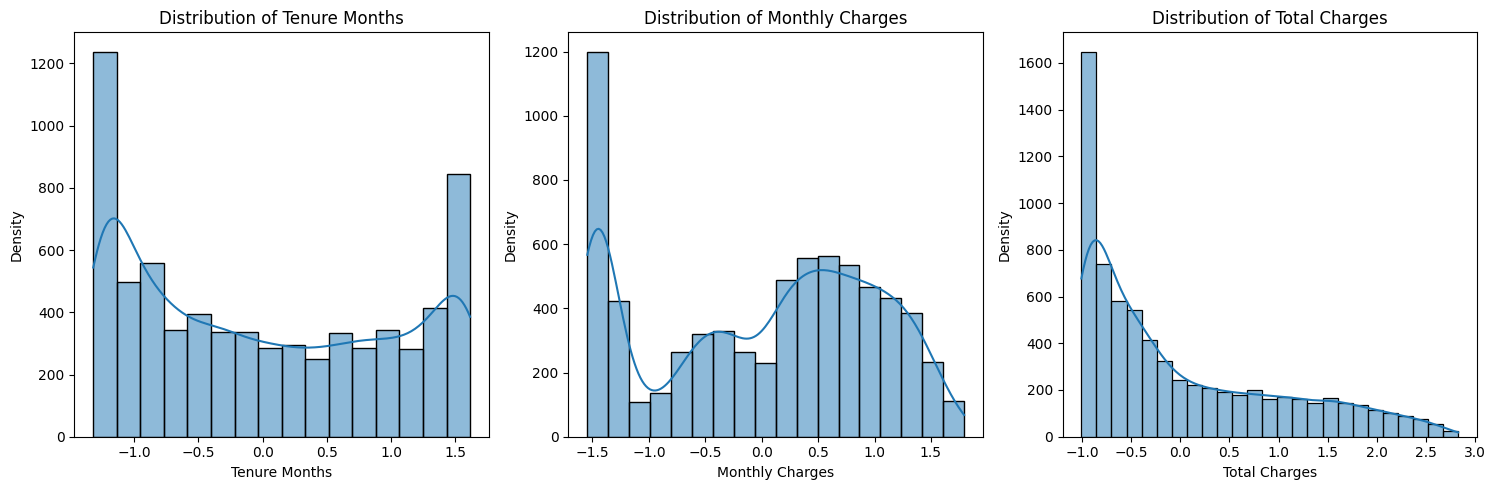

In [ ]:
# Plot distributions of numerical features after scaling
# We'll use the original (non-scaled) numerical columns for more interpretable distributions if needed,
# but since we have X_processed_df, let's look at their distributions.

# Get numerical columns from the preprocessed dataframe
numerical_cols_processed = ['Tenure Months', 'Monthly Charges', 'Total Charges']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols_processed):
    plt.subplot(1, 3, i + 1)
    sns.histplot(X_processed_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

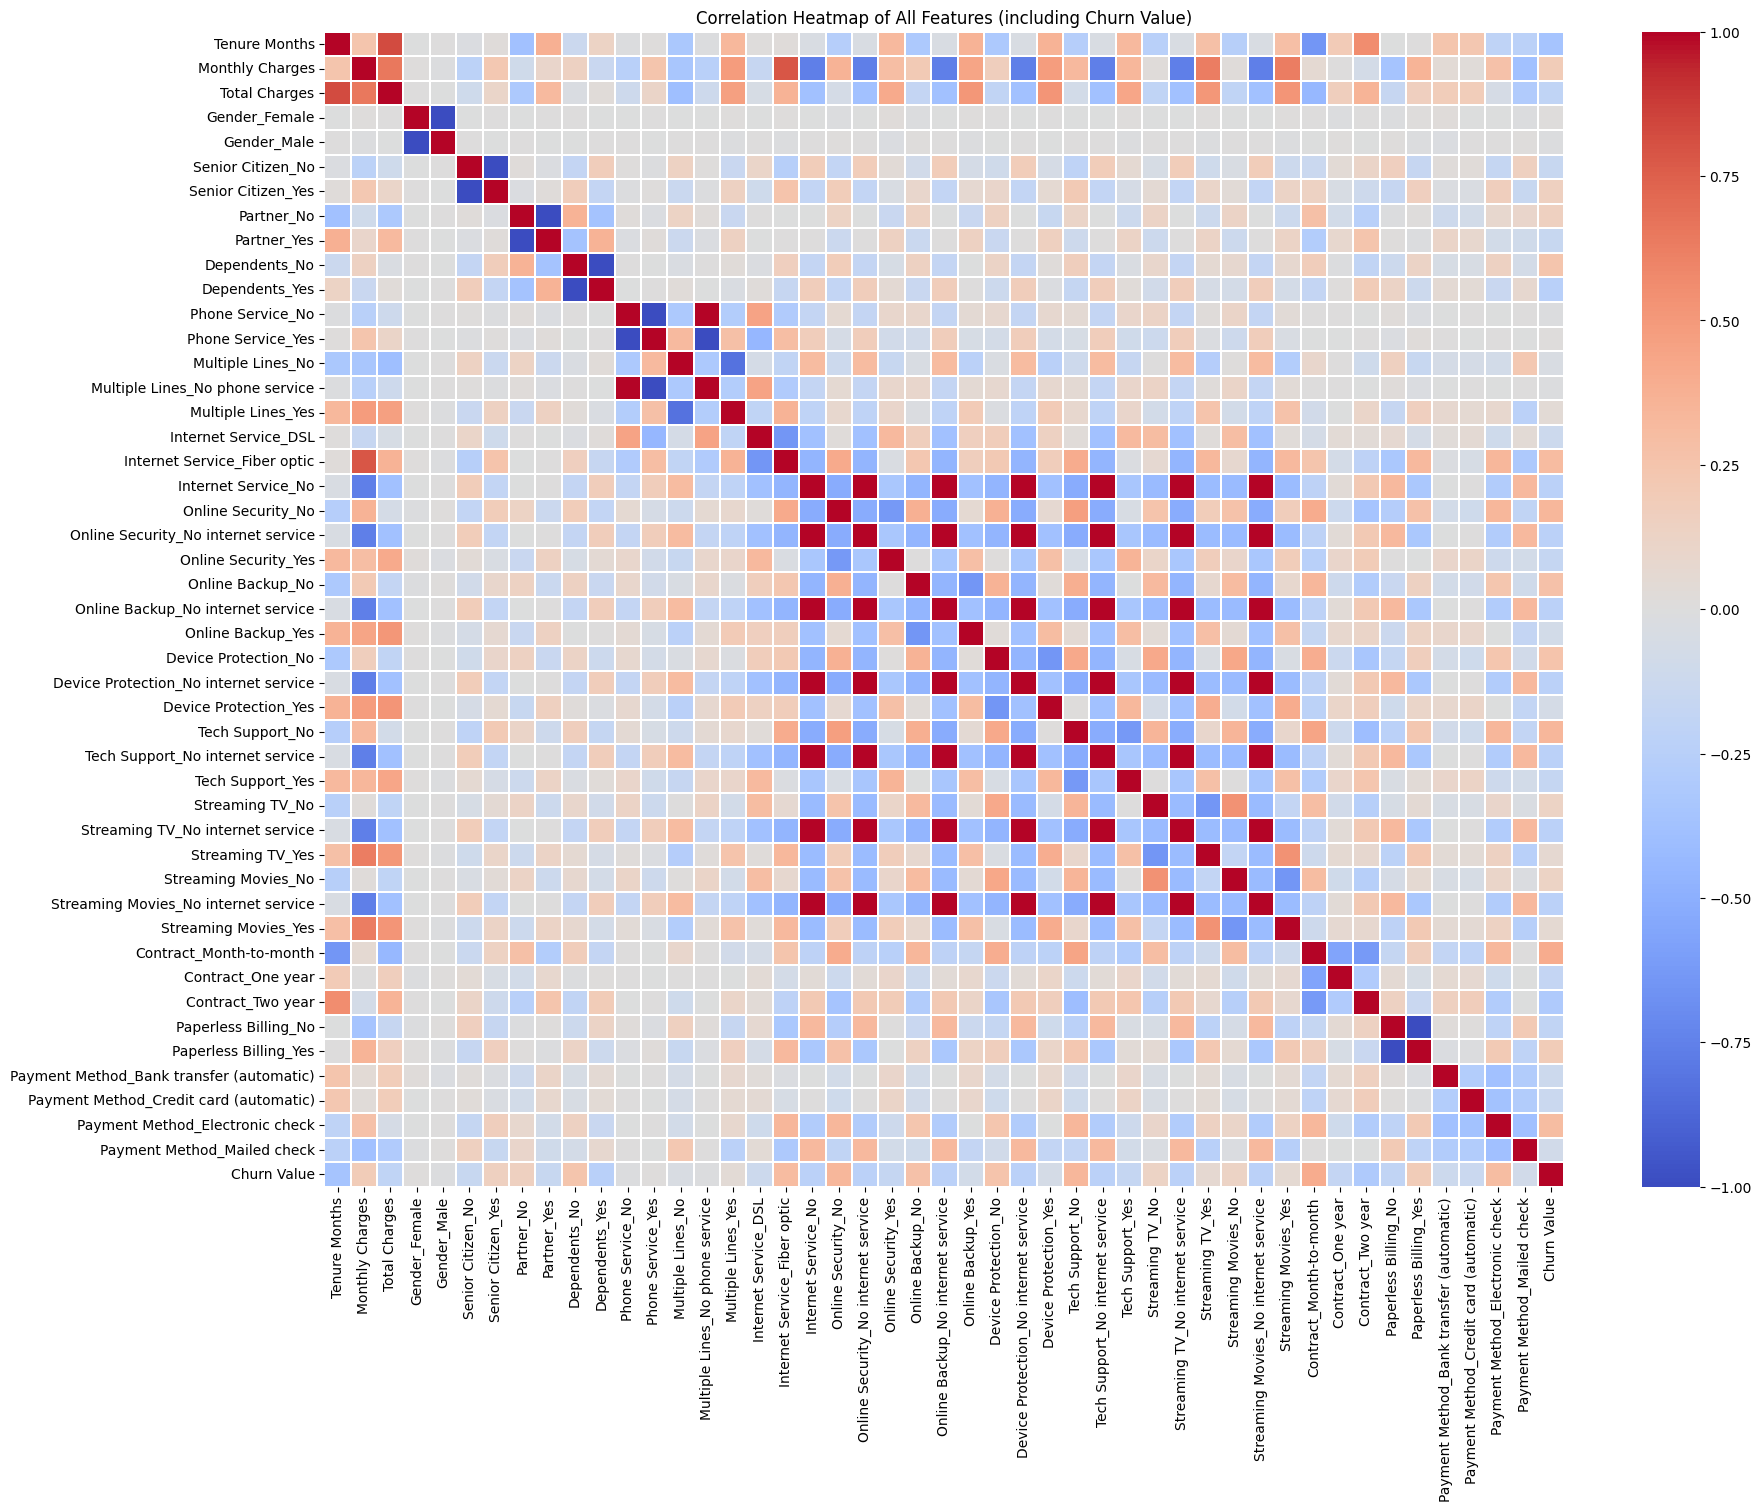


Correlation of features with 'Churn Value':
Churn Value                                 1.000000
Contract_Month-to-month                     0.405103
Online Security_No                          0.342637
Tech Support_No                             0.337281
Internet Service_Fiber optic                0.308020
Payment Method_Electronic check             0.301919
Online Backup_No                            0.268005
Device Protection_No                        0.252481
Dependents_No                               0.248542
Monthly Charges                             0.193356
Paperless Billing_Yes                       0.191825
Senior Citizen_Yes                          0.150889
Partner_No                                  0.150448
Streaming Movies_No                         0.130845
Streaming TV_No                             0.128916
Streaming TV_Yes                            0.063228
Streaming Movies_Yes                        0.061382
Multiple Lines_Yes                          0.040102
P

In [ ]:
# Create a DataFrame that includes the target variable for correlation analysis
df_for_corr = X_processed_df.copy()
df_for_corr['Churn Value'] = y.values # Ensure target variable is included and aligned

plt.figure(figsize=(20, 15))
sns.heatmap(df_for_corr.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of All Features (including Churn Value)')
plt.show()

# Display correlations with the target variable 'Churn Value' specifically
print("\nCorrelation of features with 'Churn Value':")
print(df_for_corr.corr()['Churn Value'].sort_values(ascending=False))

## 4. Split Dataset into Train/Test

In [ ]:
# Split the preprocessed data into training and testing sets
# We use a stratify strategy to maintain the same churn distribution in both train and test sets
# This is important given the class imbalance observed in the EDA.

X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (5634, 46)
Shape of X_test: (1409, 46)
Shape of y_train: (5634,)
Shape of y_test: (1409,)

Distribution of Churn in training set:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64


## 5. Train Multiple Models

In [ ]:
# Function to train and evaluate a model
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)

    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report
    }

# Initialize and train Logistic Regression model
logistic_regression_model = LogisticRegression(random_state=42, solver='liblinear')
lr_results = train_and_evaluate_model(logistic_regression_model, X_train, y_train, X_test, y_test, "Logistic Regression")

# Initialize and train Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
rf_results = train_and_evaluate_model(random_forest_model, X_train, y_train, X_test, y_test, "Random Forest")

# Initialize and train XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_results = train_and_evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")

# Store results for comparison
all_model_results = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}



--- Training Logistic Regression ---

Logistic Regression Performance:
Accuracy: 0.8013
Precision: 0.6416
Recall: 0.5695
F1-Score: 0.6034

Confusion Matrix:
[[916 119]
 [161 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


--- Training Random Forest ---

Random Forest Performance:
Accuracy: 0.7871
Precision: 0.6259
Recall: 0.4920
F1-Score: 0.5509

Confusion Matrix:
[[925 110]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
wei

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. Split Dataset into Train/Test

In [ ]:
# Split the preprocessed data into training and testing sets
# We use a stratify strategy to maintain the same churn distribution in both train and test sets
# This is important given the class imbalance observed in the EDA.

X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (5634, 46)
Shape of X_test: (1409, 46)
Shape of y_train: (5634,)
Shape of y_test: (1409,)

Distribution of Churn in training set:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True) * 100)

Shape of X_train: (5634, 46)
Shape of X_test: (1409, 46)
Shape of y_train: (5634,)
Shape of y_test: (1409,)

Distribution of Churn in training set:
Churn Value
0    73.464679
1    26.535321
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn Value
0    73.456352
1    26.543648
Name: proportion, dtype: float64


## 5. Train Multiple Models

In [ ]:
# Function to train and evaluate a model
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)

    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report
    }

# Initialize and train Logistic Regression model
logistic_regression_model = LogisticRegression(random_state=42, solver='liblinear')
lr_results = train_and_evaluate_model(logistic_regression_model, X_train, y_train, X_test, y_test, "Logistic Regression")

# Initialize and train Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
rf_results = train_and_evaluate_model(random_forest_model, X_train, y_train, X_test, y_test, "Random Forest")

# Initialize and train XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_results = train_and_evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")

# Store results for comparison
all_model_results = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}



--- Training Logistic Regression ---

Logistic Regression Performance:
Accuracy: 0.8013
Precision: 0.6416
Recall: 0.5695
F1-Score: 0.6034

Confusion Matrix:
[[916 119]
 [161 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


--- Training Random Forest ---

Random Forest Performance:
Accuracy: 0.7871
Precision: 0.6259
Recall: 0.4920
F1-Score: 0.5509

Confusion Matrix:
[[925 110]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
wei

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. Hyperparameter Tuning for the Best Model (Logistic Regression)

In [ ]:
# Hyperparameter tuning for Logistic Regression using GridSearchCV
print("\n--- Starting Hyperparameter Tuning for Logistic Regression ---")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1', # Use f1-score as the primary metric due to class imbalance
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("\nBest parameters found for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score on cross-validation set:", grid_search_lr.best_score_)

# Get the best Logistic Regression model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best Logistic Regression model on the test set
print("\n--- Evaluating Tuned Logistic Regression Model ---")
tuned_lr_results = train_and_evaluate_model(best_lr_model, X_train, y_train, X_test, y_test, "Tuned Logistic Regression")

# Update all_model_results with the tuned model
all_model_results["Tuned Logistic Regression"] = tuned_lr_results


--- Starting Hyperparameter Tuning for Logistic Regression ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-score on cross-validation set: 0.6242117042370303

--- Evaluating Tuned Logistic Regression Model ---

--- Training Tuned Logistic Regression ---

Tuned Logistic Regression Performance:
Accuracy: 0.7970
Precision: 0.6310
Recall: 0.5668
F1-Score: 0.5972

Confusion Matrix:
[[911 124]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 7. Compare Models and Select Best One

In [ ]:
# Compare performance of all models
print("\n--- Model Comparison ---")

performance_summary = pd.DataFrame({
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
})

for model_name, results in all_model_results.items():
    performance_summary.loc[len(performance_summary)] = [
        model_name,
        results['accuracy'],
        results['precision'],
        results['recall'],
        results['f1_score']
    ]

performance_summary = performance_summary.sort_values(by='F1-Score', ascending=False)
display(performance_summary)

# Select the best model based on F1-Score
best_model_name = performance_summary.iloc[0]['Model']
best_model_final = all_model_results[best_model_name]['model']

print(f"\nBased on F1-Score, the best model is: {best_model_name}")


--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.801278,0.641566,0.569519,0.603399
3,Tuned Logistic Regression,0.797019,0.630952,0.566845,0.597183
2,XGBoost,0.786373,0.607038,0.553476,0.579021
1,Random Forest,0.787083,0.625850,0.491979,0.550898



Based on F1-Score, the best model is: Logistic Regression


## 8. Save the Final Model

In [ ]:
# Save the best model using pickle
model_filename = 'best_churn_prediction_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_final, file)

print(f"\nBest model ({best_model_name}) saved as {model_filename}")


Best model (Logistic Regression) saved as best_churn_prediction_model.pkl


## 7. Compare Models and Select Best One

In [ ]:
# Compare performance of all models
print("\n--- Model Comparison ---")

performance_summary = pd.DataFrame({
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
})

for model_name, results in all_model_results.items():
    performance_summary.loc[len(performance_summary)] = [
        model_name,
        results['accuracy'],
        results['precision'],
        results['recall'],
        results['f1_score']
    ]

performance_summary = performance_summary.sort_values(by='F1-Score', ascending=False)
display(performance_summary)

# Select the best model based on F1-Score
best_model_name = performance_summary.iloc[0]['Model']
best_model_final = all_model_results[best_model_name]['model']

print(f"\nBased on F1-Score, the best model is: {best_model_name}")


--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.801278,0.641566,0.569519,0.603399
3,Tuned Logistic Regression,0.797019,0.630952,0.566845,0.597183
2,XGBoost,0.786373,0.607038,0.553476,0.579021
1,Random Forest,0.787083,0.625850,0.491979,0.550898



Based on F1-Score, the best model is: Logistic Regression


## 8. Save the Final Model

In [ ]:
# Save the best model using pickle
model_filename = 'best_churn_prediction_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_final, file)

print(f"\nBest model ({best_model_name}) saved as {model_filename}")


Best model (Logistic Regression) saved as best_churn_prediction_model.pkl


## 5. Train Multiple Models

In [ ]:
# Function to train and evaluate a model
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    print(f"\n--- Training {model_name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nConfusion Matrix:")
    print(conf_matrix)
    print("\nClassification Report:")
    print(class_report)

    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report
    }

# Initialize and train Logistic Regression model
logistic_regression_model = LogisticRegression(random_state=42, solver='liblinear')
lr_results = train_and_evaluate_model(logistic_regression_model, X_train, y_train, X_test, y_test, "Logistic Regression")

# Initialize and train Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
rf_results = train_and_evaluate_model(random_forest_model, X_train, y_train, X_test, y_test, "Random Forest")

# Initialize and train XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_results = train_and_evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")

# Store results for comparison
all_model_results = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}



--- Training Logistic Regression ---

Logistic Regression Performance:
Accuracy: 0.8013
Precision: 0.6416
Recall: 0.5695
F1-Score: 0.6034

Confusion Matrix:
[[916 119]
 [161 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


--- Training Random Forest ---

Random Forest Performance:
Accuracy: 0.7871
Precision: 0.6259
Recall: 0.4920
F1-Score: 0.5509

Confusion Matrix:
[[925 110]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
wei

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:24:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Performance:
Accuracy: 0.7864
Precision: 0.6070
Recall: 0.5535
F1-Score: 0.5790

Confusion Matrix:
[[901 134]
 [167 207]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1035
           1       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## 6. Hyperparameter Tuning for the Best Model (Logistic Regression)

In [ ]:
# Hyperparameter tuning for Logistic Regression using GridSearchCV
print("\n--- Starting Hyperparameter Tuning for Logistic Regression ---")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1', # Use f1-score as the primary metric due to class imbalance
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("\nBest parameters found for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score on cross-validation set:", grid_search_lr.best_score_)

# Get the best Logistic Regression model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best Logistic Regression model on the test set
print("\n--- Evaluating Tuned Logistic Regression Model ---")
tuned_lr_results = train_and_evaluate_model(best_lr_model, X_train, y_train, X_test, y_test, "Tuned Logistic Regression")

# Update all_model_results with the tuned model
all_model_results["Tuned Logistic Regression"] = tuned_lr_results


--- Starting Hyperparameter Tuning for Logistic Regression ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-score on cross-validation set: 0.6242117042370303

--- Evaluating Tuned Logistic Regression Model ---

--- Training Tuned Logistic Regression ---

Tuned Logistic Regression Performance:
Accuracy: 0.7970
Precision: 0.6310
Recall: 0.5668
F1-Score: 0.5972

Confusion Matrix:
[[911 124]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 6. Hyperparameter Tuning for the Best Model (Logistic Regression)

In [ ]:
# Hyperparameter tuning for Logistic Regression using GridSearchCV
print("\n--- Starting Hyperparameter Tuning for Logistic Regression ---")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1', # Use f1-score as the primary metric due to class imbalance
    n_jobs=-1, # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("\nBest parameters found for Logistic Regression:", grid_search_lr.best_params_)
print("Best F1-score on cross-validation set:", grid_search_lr.best_score_)

# Get the best Logistic Regression model
best_lr_model = grid_search_lr.best_estimator_

# Evaluate the best Logistic Regression model on the test set
print("\n--- Evaluating Tuned Logistic Regression Model ---")
tuned_lr_results = train_and_evaluate_model(best_lr_model, X_train, y_train, X_test, y_test, "Tuned Logistic Regression")

# Update all_model_results with the tuned model
all_model_results["Tuned Logistic Regression"] = tuned_lr_results


--- Starting Hyperparameter Tuning for Logistic Regression ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters found for Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1-score on cross-validation set: 0.6242117042370303

--- Evaluating Tuned Logistic Regression Model ---

--- Training Tuned Logistic Regression ---

Tuned Logistic Regression Performance:
Accuracy: 0.7970
Precision: 0.6310
Recall: 0.5668
F1-Score: 0.5972

Confusion Matrix:
[[911 124]
 [162 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## 7. Compare Models and Select Best One

In [ ]:
# Compare performance of all models
print("\n--- Model Comparison ---")

performance_summary = pd.DataFrame({
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
})

for model_name, results in all_model_results.items():
    performance_summary.loc[len(performance_summary)] = [
        model_name,
        results['accuracy'],
        results['precision'],
        results['recall'],
        results['f1_score']
    ]

performance_summary = performance_summary.sort_values(by='F1-Score', ascending=False)
display(performance_summary)

# Select the best model based on F1-Score
best_model_name = performance_summary.iloc[0]['Model']
best_model_final = all_model_results[best_model_name]['model']

print(f"\nBased on F1-Score, the best model is: {best_model_name}")


--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.801278,0.641566,0.569519,0.603399
3,Tuned Logistic Regression,0.797019,0.630952,0.566845,0.597183
2,XGBoost,0.786373,0.607038,0.553476,0.579021
1,Random Forest,0.787083,0.625850,0.491979,0.550898



Based on F1-Score, the best model is: Logistic Regression


## 8. Save the Final Model

In [ ]:
# Save the best model using pickle
model_filename = 'best_churn_prediction_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_final, file)

print(f"\nBest model ({best_model_name}) saved as {model_filename}")


Best model (Logistic Regression) saved as best_churn_prediction_model.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Load dataset
df = pd.read_excel('/content/Telco_customer_churn.xlsx')

# Select ONLY required features
df = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract', 'Churn Value']]

# Fix Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

# Encode Contract
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
df['Contract'] = df['Contract'].map(contract_map)

# Features & target
X = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Contract']]
y = df['Churn Value']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save BOTH model + scaler
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("Model and scaler saved successfully")

Accuracy: 0.7757274662881476
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1009
           1       0.63      0.51      0.56       400

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.71      1409
weighted avg       0.77      0.78      0.77      1409

Model and scaler saved successfully


/tmp/ipykernel_3891/213443454.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
